<a href="https://colab.research.google.com/github/RB1Student/ISYS2001-Assignment-2-Project/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [162]:
import pandas as pd
import matplotlib

In [164]:
#Grab the name of the user

User = input("What is your name? ")

What is your name? Ross


In [165]:
#Import bank statement

print("-- Could youn please upload your bank statement hear in CSV Format--")

from google.colab import files
uploaded = files.upload()


-- Could youn please upload your bank statement hear in CSV Format--


Saving Sample Bank Statement.csv to Sample Bank Statement (3).csv


In [166]:
Bank_Statement = pd.read_csv("/content/Sample Bank Statement.csv")

In [167]:
print(dataFrame)

          Date               Name     Type      Income     Expense  \
0     1/9/2026    Opening Balance  Balance           —           —   
1     5/9/2026             Salary   Income  $3,000.00            —   
2    12/9/2026        Supermarket  Expense           —    $125.40    
3    18/9/2026       Fuel Station  Expense           —     $85.00    
4    25/9/2026               Rent  Expense           —  $1,500.00    
5    30/9/2026  Transfer Received   Income    $500.00            —   
6    3/10/2026             Salary   Income  $3,000.00            —   
7    8/10/2026   Electricity Bill  Expense           —    $145.00    
8   14/10/2026      Grocery Store  Expense           —     $98.75    
9   20/10/2026         Restaurant  Expense           —     $72.50    
10  27/10/2026  Freelance Payment   Income    $750.00            —   
11  31/10/2026      Internet Bill  Expense           —     $79.00    
12   3/11/2026             Salary   Income  $3,000.00            —   
13   8/11/2026      

In [169]:
def clean_money(series):
    return (
        series.astype(str)
        .str.replace(r"[^\d.\-]", "", regex=True)  # remove $, commas, spaces, and the "—" dash
        .replace("", "0")                          # empty strings (from "—") become 0
        .astype(float)
    )

for col in ["Income", "Expense", "Balance"]:
    Bank_Statement[col] = clean_money(Bank_Statement[col])

In [180]:
#Filter Input for date and Category

import ipywidgets as widgets
from IPython.display import display
# matplotlib.pyplot is now imported and used in the separate pie chart cell (YlgnwywFEDEi)

# 1. Make Date a real date (your dates are day/month/year)
Bank_Statement["Date"] = pd.to_datetime(Bank_Statement["Date"], dayfirst=True)
Bank_Statement["Month"] = Bank_Statement["Date"].dt.strftime("%B %Y")   # e.g. "October 2026"

# 2. Build the dropdowns
month_options = ["All"] + list(Bank_Statement["Month"].unique())
category_options = ["All"] + sorted(Bank_Statement["Name"].unique())

month_dd = widgets.Dropdown(options=month_options, description="Month:")
category_dd = widgets.Dropdown(options=category_options, description="Category:")

output = widgets.Output()

# 3. Filter + recalculate whenever a dropdown changes
def update(change=None):
    global Filtered_Statement
    Filtered_Statement = Bank_Statement.copy()

    if month_dd.value != "All":
        Filtered_Statement = Filtered_Statement[Filtered_Statement["Month"] == month_dd.value]
    if category_dd.value != "All":
        Filtered_Statement = Filtered_Statement[Filtered_Statement["Name"] == category_dd.value]

    with output:
        output.clear_output()
        if Filtered_Statement.empty:
            print("No transactions match those filters.")
            return

        # Current Balance
        Current_Balance = Filtered_Statement["Balance"].iloc[-1]
        print(f"Current Balance: ${Current_Balance:,.2f}")

        # Total Income Earned
        Total_Income = Filtered_Statement["Income"].sum()
        print(f"Total Income:    ${Total_Income:,.2f}")

        # Total Expense
        Total_Expense = Filtered_Statement["Expense"].sum()
        print(f"Total Expense:   ${Total_Expense:,.2f}")

        display(Filtered_Statement.drop(columns="Month"))

        # Call the pie chart function defined in cell YlgnwywFEDEi
        generate_expense_pie_chart(Filtered_Statement)


month_dd.observe(update, names="value")
category_dd.observe(update, names="value")

display(month_dd, category_dd, output)
update()   # show results on first load

Dropdown(description='Month:', options=('All', 'September 2026', 'October 2026', 'November 2026'), value='All'…

Dropdown(description='Category:', options=('All', 'Clothing Store', 'Coffee Shop', 'Electricity Bill', 'Freela…

Output()

In [171]:
#Current Balance

# Opening balance (run this once, outside update())
Opening_Balance = Bank_Statement.loc[Bank_Statement["Type"] == "Balance", "Balance"].iloc[0]

# Inside update(), after Filtered_Statement is built:
Total_Income = Filtered_Statement["Income"].sum()
Total_Expense = Filtered_Statement["Expense"].sum()

Current_Balance = Opening_Balance + Total_Income - Total_Expense
print(f"${Current_Balance:,.2f}")

$11,635.25


In [172]:
#Total Income Earned

Total_Income = Filtered_Statement['Income'].sum()

print(f'${Total_Income:.2f}')

$10650.00


In [173]:
#Total Expense Earned

Total_Expense = Filtered_Statement['Expense'].sum()

print(f'${Total_Expense:.2f}')

$4014.75


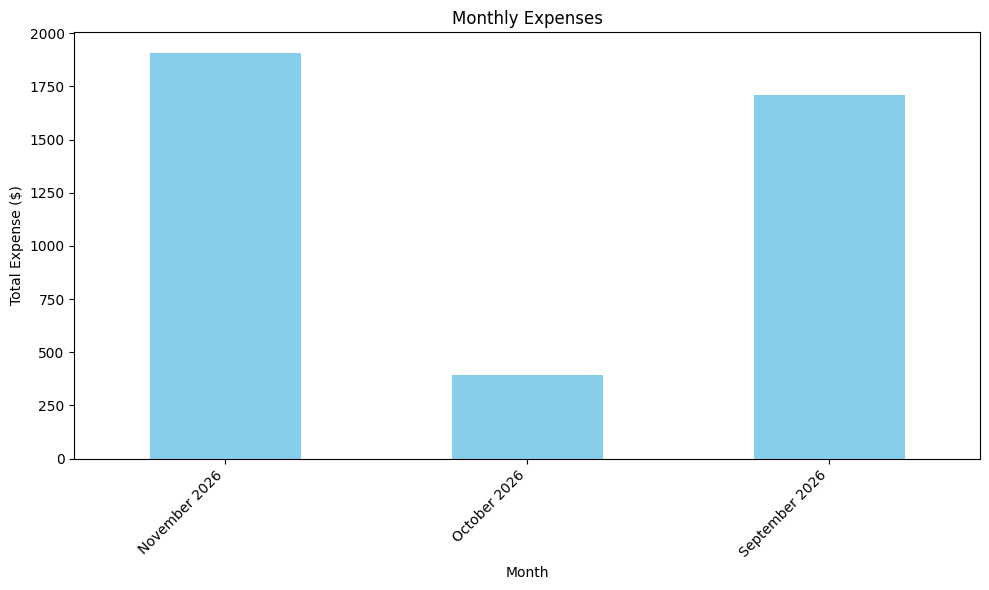

In [174]:
# Bar Char of Monthly Expense
import matplotlib.pyplot as plt

if not Filtered_Statement.empty:
    monthly_expense = Filtered_Statement.groupby('Month')['Expense'].sum()

    plt.figure(figsize=(10, 6))
    monthly_expense.plot(kind='bar', color='skyblue')
    plt.title('Monthly Expenses')
    plt.xlabel('Month')
    plt.ylabel('Total Expense ($)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot monthly expenses based on current filters.")

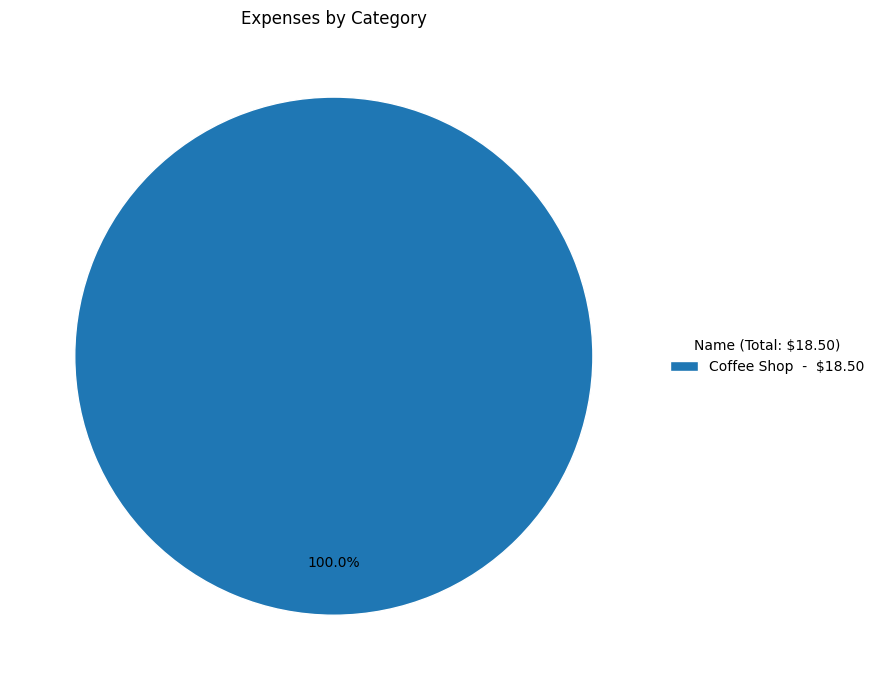

In [183]:
# Pie Chart of Expenses by Category (with legend showing amounts)
import matplotlib.pyplot as plt

def plot_expense_pie(df, category_col='Name', top_n=8):
    if df.empty:
        print("No data available to plot expense categories based on current filters.")
        return

    category_expense = (
        df.groupby(category_col)['Expense'].sum()
        .loc[lambda s: s > 0]                 # pie charts can't show zero/negative values
        .sort_values(ascending=False)
    )

    if category_expense.empty:
        print("No positive expenses to plot for the current filters.")
        return

    # Group small categories into "Other" so the chart stays readable
    if len(category_expense) > top_n:
        top = category_expense.iloc[:top_n]
        other = category_expense.iloc[top_n:].sum()
        category_expense = top.copy()
        category_expense['Other'] = other

    total = category_expense.sum()

    fig, ax = plt.subplots(figsize=(11, 7))
    wedges, texts, autotexts = ax.pie(
        category_expense,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        pctdistance=0.8,
        wedgeprops={'edgecolor': 'white'}
    )

    # Key: name + expense amount
    legend_labels = [f"{name}  -  ${amount:,.2f}" for name, amount in category_expense.items()]
    ax.legend(
        wedges,
        legend_labels,
        title=f"{category_col} (Total: ${total:,.2f})",
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        frameon=False
    )

    ax.set_title('Expenses by Category')
    plt.tight_layout()
    plt.show()

plot_expense_pie(Filtered_Statement)